In [1]:
import pandas as pd


In [2]:
import os
os.listdir("../data")

['dim_customer.csv',
 'dim_delivery_partner_.csv',
 'dim_menu_item.csv',
 'dim_restaurant.csv',
 'fact_delivery_performance.csv',
 'fact_orders.csv',
 'fact_order_items.csv',
 'fact_ratings.csv']

In [3]:
customers =pd.read_csv("../data/dim_customer.csv")
delivery_partners = pd.read_csv("../data/dim_delivery_partner_.csv")
menu_items = pd.read_csv("../data/dim_menu_item.csv")
restaurants = pd.read_csv("../data/dim_restaurant.csv")

order = pd.read_csv("../data/fact_orders.csv")
delivery = pd.read_csv('../data/fact_delivery_performance.csv')
ratings = pd.read_csv('../data/fact_ratings.csv')

# Merge all the main tables 
first join orders + delivery performance 

In [4]:
orders_delivery = order.merge(delivery, on="order_id", how="left")

now we are joiing rating with that 

In [5]:
orders_delivery_ratings = orders_delivery.merge(ratings, on="order_id", how="left")

Now we are adding customer information

In [6]:
print(orders_delivery_ratings.columns.tolist)
print(customers.columns.tolist)

<bound method IndexOpsMixin.tolist of Index(['order_id', 'customer_id_x', 'restaurant_id_x', 'delivery_partner_id',
       'order_timestamp', 'subtotal_amount', 'discount_amount', 'delivery_fee',
       'total_amount', 'is_cod', 'is_cancelled', 'actual_delivery_time_mins',
       'expected_delivery_time_mins', 'distance_km', 'customer_id_y',
       'restaurant_id_y', 'rating', 'review_text', 'review_timestamp',
       'sentiment_score'],
      dtype='object')>
<bound method IndexOpsMixin.tolist of Index(['customer_id', 'signup_date', 'city', 'acquisition_channel',
       'Unnamed: 4'],
      dtype='object')>


In [7]:
#orders_delivery_ratings = orders_delivery_ratings.drop(columns=["customer_id_y","restaurant_id_y"])
orders_delivery_ratings = orders_delivery_ratings.rename(columns={
    "customer_id_x":"customer_id",
    "restaurant_id_x":"restaurant_id"
})

In [8]:
data = orders_delivery_ratings.merge(customers, on="customer_id", how="left")

In [9]:
print(data.columns.tolist())

['order_id', 'customer_id', 'restaurant_id', 'delivery_partner_id', 'order_timestamp', 'subtotal_amount', 'discount_amount', 'delivery_fee', 'total_amount', 'is_cod', 'is_cancelled', 'actual_delivery_time_mins', 'expected_delivery_time_mins', 'distance_km', 'customer_id_y', 'restaurant_id_y', 'rating', 'review_text', 'review_timestamp', 'sentiment_score', 'signup_date', 'city', 'acquisition_channel', 'Unnamed: 4']


Now add restaurant information 

In [10]:
data = data.merge(restaurants, on="restaurant_id", how="left")

Add delivery partner info 

In [11]:
data = data.merge(delivery_partners, on="delivery_partner_id", how="left")

# Now we have one final dataset for analysis 
create crisis phase column

In [12]:
data['order_timestamp'] = pd.to_datetime(data['order_timestamp'])

data['phase'] = data['order_timestamp'].apply(lambda x: 'Pre-Crisis' if x.month <= 5 else 'Crisis')

Let's Prepare final dataset property

In [13]:
data['order_timestamp'] = pd.to_datetime(data['order_timestamp'])
data['month'] = data['order_timestamp'].dt.to_period('M').astype(str)
data['year'] = data['order_timestamp'].dt.year
data['month_num'] = data['order_timestamp'].dt.month

Fix the phase column a little better

In [14]:
data['phase'] = data['month_num'].apply(
    lambda x: 'Pre-Crisis' if x <= 5 else 'Crisis'
)

# Now data cleaning first 

In [15]:
data.shape

(149166, 40)

In [16]:
data.isnull().sum()

order_id                            0
customer_id                         0
restaurant_id                       0
delivery_partner_id              5635
order_timestamp                     0
subtotal_amount                     0
discount_amount                     0
delivery_fee                        0
total_amount                        0
is_cod                              0
is_cancelled                        0
actual_delivery_time_mins           0
expected_delivery_time_mins         0
distance_km                         0
customer_id_y                   80341
restaurant_id_y                 80341
rating                          80341
review_text                     80341
review_timestamp                80341
sentiment_score                 80341
signup_date                      5053
city_x                           5053
acquisition_channel              5053
Unnamed: 4                     149166
restaurant_name                     0
city_y                              0
cuisine_type

In [17]:
(data.isnull().sum() / len(data)) * 100

order_id                         0.000000
customer_id                      0.000000
restaurant_id                    0.000000
delivery_partner_id              3.777671
order_timestamp                  0.000000
subtotal_amount                  0.000000
discount_amount                  0.000000
delivery_fee                     0.000000
total_amount                     0.000000
is_cod                           0.000000
is_cancelled                     0.000000
actual_delivery_time_mins        0.000000
expected_delivery_time_mins      0.000000
distance_km                      0.000000
customer_id_y                   53.860129
restaurant_id_y                 53.860129
rating                          53.860129
review_text                     53.860129
review_timestamp                53.860129
sentiment_score                 53.860129
signup_date                      3.387501
city_x                           3.387501
acquisition_channel              3.387501
Unnamed: 4                     100

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149166 entries, 0 to 149165
Data columns (total 40 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   order_id                     149166 non-null  object        
 1   customer_id                  149166 non-null  object        
 2   restaurant_id                149166 non-null  object        
 3   delivery_partner_id          143531 non-null  object        
 4   order_timestamp              149166 non-null  datetime64[ns]
 5   subtotal_amount              149166 non-null  float64       
 6   discount_amount              149166 non-null  float64       
 7   delivery_fee                 149166 non-null  float64       
 8   total_amount                 149166 non-null  float64       
 9   is_cod                       149166 non-null  object        
 10  is_cancelled                 149166 non-null  object        
 11  actual_delivery_time_mins 

In [19]:
data.duplicated().sum()

np.int64(0)

In [20]:
data = data.drop_duplicates()

Proper cleaning steps we should follow
Step 1 — Drop fully useless columns

In [21]:
data = data.drop(columns=['Unnamed: 4'], errors='ignore')

Step 2 — Rename confusing columns

In [22]:
data = data.rename(columns={
    'city_x':'customer_city',
    'city_y': 'restaurants_city',
    'city' : 'partner_city',
    'is_active_x' : 'restaurant_is_active',
    'is_active_y' : 'partner_is_active'
})

In [23]:
object_cols = data.select_dtypes(include='object').columns

for col in object_cols:
    print(f"\nColumn: {col}")
    print(data[col].dropna().unique()[:10])


Column: order_id
['ORD202501023439' 'ORD202501012051' 'ORD202501019281' 'ORD202501000124'
 'ORD202501006518' 'ORD202501018255' 'ORD202501004299' 'ORD202501018036'
 'ORD202501009329' 'ORD202501007498']

Column: customer_id
['CUST181110' 'CUST025572' 'CUST179306' 'CUST191820' 'CUST033760'
 'CUST011850' 'CUST107475' 'CUST093042' 'CUST104825' 'CUST135654']

Column: restaurant_id
['REST08622' 'REST02383' 'REST14069' 'REST19745' 'REST12962' 'REST01307'
 'REST12542' 'REST13907' 'REST10267' 'REST05434']

Column: delivery_partner_id
['DP05541' 'DP08091' 'DP02021' 'DP13859' 'DP09615' 'DP14063' 'DP07728'
 'DP01276' 'DP03078' 'DP11625']

Column: is_cod
['N' 'Y']

Column: is_cancelled
['N' 'Y']

Column: customer_id_y
['CUST181110' 'CUST179306' 'CUST093042' 'CUST110825' 'CUST181669'
 'CUST024044' 'CUST139611' 'CUST078091' 'CUST035317' 'CUST092566']

Column: restaurant_id_y
['REST08622' 'REST14069' 'REST13907' 'REST08451' 'REST00225' 'REST16733'
 'REST13916' 'REST12102' 'REST03046' 'REST01441']

Col

Step 4 — Fix Boolean Columns

In [24]:
clean_data = data.copy()

In [25]:
clean_data['is_cod'] = clean_data['is_cod'].map({'Y':1,'N':0})
clean_data['is_cancelled'] = clean_data['is_cancelled'].map({'Y':1,'N':0})
clean_data['restaurant_is_active'] = clean_data['restaurant_is_active'].map({'Y':1,'N':0})
clean_data['partner_is_active'] = clean_data['partner_is_active'].map({'Y':1,'N':0})

In [26]:
clean_data['signup_data'] = pd.to_datetime(clean_data['signup_date'],dayfirst=True, errors='coerce')
clean_data['review_timestamp'] = pd.to_datetime(clean_data['review_timestamp'], dayfirst=True,errors='coerce')

In [27]:
clean_data['review_text'] = clean_data['review_text'].fillna('No Review')
clean_data['rating'] = clean_data['rating'].fillna(0)
clean_data['sentiment_score'] = clean_data['sentiment_score'].fillna(0)

In [28]:
clean_data['customer_city'] = clean_data['customer_city'].fillna('Unknown')
clean_data['acquisition_channel'] = clean_data['acquisition_channel'].fillna('Unknown')

In [29]:
clean_data['partner_name'] = clean_data['partner_name'].fillna('Unknown')
clean_data['partner_city'] = clean_data['partner_city'].fillna('Unknown')
clean_data['vehicle_type'] = clean_data['vehicle_type'].fillna('Unknown')
clean_data['employment_type'] = clean_data['employment_type'].fillna('Unknown')
clean_data['avg_rating'] = clean_data['avg_rating'].fillna(0)
clean_data['partner_is_active'] = clean_data['partner_is_active'].fillna(0)

In [30]:
clean_data['avg_prep_time_min'] = clean_data['avg_prep_time_min'].astype('category')

In [31]:
clean_data = clean_data.drop(columns=['restaurant_name'])

In [32]:
clean_data.isnull().sum()

order_id                           0
customer_id                        0
restaurant_id                      0
delivery_partner_id             5635
order_timestamp                    0
subtotal_amount                    0
discount_amount                    0
delivery_fee                       0
total_amount                       0
is_cod                             0
is_cancelled                       0
actual_delivery_time_mins          0
expected_delivery_time_mins        0
distance_km                        0
customer_id_y                  80341
restaurant_id_y                80341
rating                             0
review_text                        0
review_timestamp               80341
sentiment_score                    0
signup_date                     5053
customer_city                      0
acquisition_channel                0
restaurants_city                   0
cuisine_type                       0
partner_type                       0
avg_prep_time_min                  0
r

In [33]:
clean_data.duplicated().sum()
clean_data['order_id'].duplicated().sum()

np.int64(0)

In [34]:
clean_data['is_cod'] = clean_data['is_cod'].str.strip().map({'Y':1, 'N':0})

AttributeError: Can only use .str accessor with string values!

In [ ]:
clean_data['is_cod'].unique()

array([nan])

In [ ]:
clean_data['is_cod'] = data['is_cod'].map({'Y':1, 'N':0})

In [ ]:
clean_data['is_cod'].value_counts()

is_cod
0    102351
1     46815
Name: count, dtype: int64

In [ ]:
clean_data.isnull().sum()

order_id                           0
customer_id                        0
restaurant_id                      0
delivery_partner_id             5635
order_timestamp                    0
subtotal_amount                    0
discount_amount                    0
delivery_fee                       0
total_amount                       0
is_cod                             0
is_cancelled                       0
actual_delivery_time_mins          0
expected_delivery_time_mins        0
distance_km                        0
rating                             0
review_text                        0
review_timestamp               80341
sentiment_score                    0
signup_date                     5053
customer_city                      0
acquisition_channel                0
restaurants_city                   0
cuisine_type                       0
partner_type                       0
avg_prep_time_min                  0
restaurant_is_active               0
partner_name                       0
p

In [ ]:
clean_data = clean_data.drop(columns=['signup_data'], errors='ignore')

In [ ]:
clean_data.isnull().sum()

order_id                           0
customer_id                        0
restaurant_id                      0
delivery_partner_id             5635
order_timestamp                    0
subtotal_amount                    0
discount_amount                    0
delivery_fee                       0
total_amount                       0
is_cod                             0
is_cancelled                       0
actual_delivery_time_mins          0
expected_delivery_time_mins        0
distance_km                        0
rating                             0
review_text                        0
review_timestamp               80341
sentiment_score                    0
signup_date                     5053
customer_city                      0
acquisition_channel                0
restaurants_city                   0
cuisine_type                       0
partner_type                       0
avg_prep_time_min                  0
restaurant_is_active               0
partner_name                       0
p

# save the clean dataset

In [ ]:
clean_data.to_csv("clean_food_delivery_data.csv", index=False)
clean_data.head(5)
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149166 entries, 0 to 149165
Data columns (total 39 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   order_id                     149166 non-null  object        
 1   customer_id                  149166 non-null  object        
 2   restaurant_id                149166 non-null  object        
 3   delivery_partner_id          143531 non-null  object        
 4   order_timestamp              149166 non-null  datetime64[ns]
 5   subtotal_amount              149166 non-null  float64       
 6   discount_amount              149166 non-null  float64       
 7   delivery_fee                 149166 non-null  float64       
 8   total_amount                 149166 non-null  float64       
 9   is_cod                       149166 non-null  int64         
 10  is_cancelled                 149166 non-null  int64         
 11  actual_delivery_time_mins 

# Question 1 : Monthly Order
compare total order across pre-crisis vs crisis 

In [ ]:
clean_data[['month','order_id']].groupby('month').count()

,order_id
month,
2025-01,23539
2025-02,22667
2025-03,23543
2025-04,21466
2025-05,22591
2025-06,9293
2025-07,8818
2025-08,8555
2025-09,8694


# Split Pre-crisi vs crisis

In [ ]:
pre_crisis = clean_data[clean_data['phase'] == 'Pre-Crisis']['order_id'].count()
crisis = clean_data[clean_data['phase'] == 'Crisis']['order_id'].count()

pre_crisis,crisis

(np.int64(113806), np.int64(35360))

calculate the decline

In [ ]:
decline_pct = ((pre_crisis - crisis ) / pre_crisis ) * 100
decline_pct

np.float64(68.92958192010965)

Monthly trend table

In [ ]:
monthly_avg = clean_data.groupby('phase')['order_id'].count() / clean_data.groupby('phase')['month'].nunique()
monthly_avg

phase
Crisis         8840.0
Pre-Crisis    22761.2
dtype: float64

plot the trend 

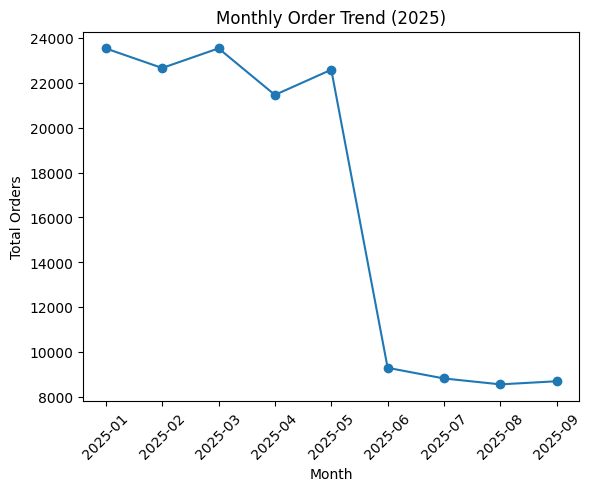

In [ ]:
import matplotlib.pyplot as plt

monthly_order = clean_data.groupby('month')['order_id'].count()

monthly_order.plot(kind= 'line', marker= 'o')
plt.title('Monthly Order Trend (2025)')
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.show()

# 2. Question Which top 5 city groups experienced the highest percentage decline in orders during the crisis period compared to the pre-crisis period? 

In [ ]:
city_order = clean_data.groupby(['customer_city', 'phase'])['order_id'].count().reset_index()

In [ ]:
city_pivot = city_order.pivot(index='customer_city', columns='phase', values='order_id').reset_index()

In [ ]:
city_pivot = city_pivot.fillna(0)

In [ ]:
city_pivot['decline_pct'] = (
    (city_pivot['Pre-Crisis'] - city_pivot['Crisis']) 
    / city_pivot['Pre-Crisis']
) * 100

In [ ]:
city_pivot = city_pivot[city_pivot['Pre-Crisis']>100]

In [ ]:
top_decline_cities = city_pivot.sort_values(by='decline_pct',ascending=False).head(5)
top_decline_cities

phase,customer_city,Crisis,Pre-Crisis,decline_pct
1,Bengaluru,9311,31277,70.230521
6,Mumbai,5322,17848,70.181533
0,Ahmedabad,2303,7648,69.887552
7,Pune,2662,8817,69.808325
3,Delhi,4704,15580,69.807445


# question 3 Among restaurants with at least 50 pre-crisis orders, which top 10 high-volume restaurants experienced the largest percentage decline in order counts during  the crisis period? 


In [ ]:
restaurant_orders = clean_data.groupby(['restaurant_id', 'phase'])['order_id'].count().reset_index()


In [ ]:
restaurant_pivot = restaurant_orders.pivot(index='restaurant_id', columns='phase', values='order_id').reset_index()


In [ ]:
restaurant_pivot = restaurant_pivot.fillna(0)


In [ ]:
restaurant_pivot.columns.name = None

In [ ]:
restaurant_pivot.columns

Index(['restaurant_id', 'Crisis', 'Pre-Crisis'], dtype='object')

In [ ]:
restaurant_pivot['decline_pct'] = (
    (restaurant_pivot['Pre-Crisis'] - restaurant_pivot['Crisis']) / restaurant_pivot['Pre-Crisis']
) * 100

In [ ]:
restaurant_pivot = restaurant_pivot[restaurant_pivot['Pre-Crisis'] > 0]

In [ ]:
high_volume_restaurants = restaurant_pivot.sort_values(by='Pre-Crisis', ascending=False).head(10)
high_volume_restaurants

,restaurant_id,Crisis,Pre-Crisis,decline_pct
16515,REST16529,2.0,21.0,90.476190
16766,REST16780,5.0,18.0,72.222222
11683,REST11694,4.0,17.0,76.470588
13399,REST13412,3.0,17.0,82.352941
11749,REST11761,2.0,16.0,87.500000
12323,REST12335,3.0,16.0,81.250000
16746,REST16760,3.0,15.0,80.000000
10871,REST10881,1.0,15.0,93.333333
18502,REST18518,2.0,15.0,86.666667
13860,REST13873,0.0,15.0,100.000000


In [ ]:
top_restaurants_decline = high_volume_restaurants.sort_values(by='decline_pct', ascending=False)
top_restaurants_decline

,restaurant_id,Crisis,Pre-Crisis,decline_pct
13860,REST13873,0.0,15.0,100.000000
10871,REST10881,1.0,15.0,93.333333
16515,REST16529,2.0,21.0,90.476190
11749,REST11761,2.0,16.0,87.500000
18502,REST18518,2.0,15.0,86.666667
13399,REST13412,3.0,17.0,82.352941
12323,REST12335,3.0,16.0,81.250000
16746,REST16760,3.0,15.0,80.000000
11683,REST11694,4.0,17.0,76.470588
16766,REST16780,5.0,18.0,72.222222


In [ ]:
top_restaurants_decline = top_restaurants_decline.merge(
    restaurants[['restaurant_id', 'restaurant_name']].drop_duplicates(),
    on='restaurant_id',
    how='left'
)

top_restaurants_decline

,restaurant_id,Crisis,Pre-Crisis,decline_pct,restaurant_name
0,REST13873,0.0,15.0,100.000000,Thindi Mane Pizza Corner
1,REST10881,1.0,15.0,93.333333,Spicy Sweets Cafe
2,REST16529,2.0,21.0,90.476190,Thindi Mane Grill Palace
3,REST11761,2.0,16.0,87.500000,Sri Mess Zone
4,REST18518,2.0,15.0,86.666667,Punjabi Curry Delight
5,REST13412,3.0,17.0,82.352941,Punjabi Darshini Palace
6,REST12335,3.0,16.0,81.250000,Hot & Crispy Express Darbar
7,REST16760,3.0,15.0,80.000000,Hot & Crispy Express Hub
8,REST11694,4.0,17.0,76.470588,Punjabi Wraps Bhojanalay
9,REST16780,5.0,18.0,72.222222,Hot & Crispy Pizza Bhojanalay


# Question 4 Cancellation Analysis: What is the cancellation rate trend pre-crisis vs crisis, and which cities are most affected?

PART 1 — Overall Cancellation Trend

In [ ]:
cancel_rate_phase = clean_data.groupby('phase')['is_cancelled'].mean().reset_index()
cancel_rate_phase

,phase,is_cancelled
0,Crisis,0.119287
1,Pre-Crisis,0.060577


In [ ]:
cancel_rate_phase['cancle_rate_%'] = cancel_rate_phase['is_cancelled']*100
cancel_rate_phase

,phase,is_cancelled,cancle_rate_%
0,Crisis,0.119287,11.928733
1,Pre-Crisis,0.060577,6.057677


🔹 PART 2 — Monthly Trend (for chart)

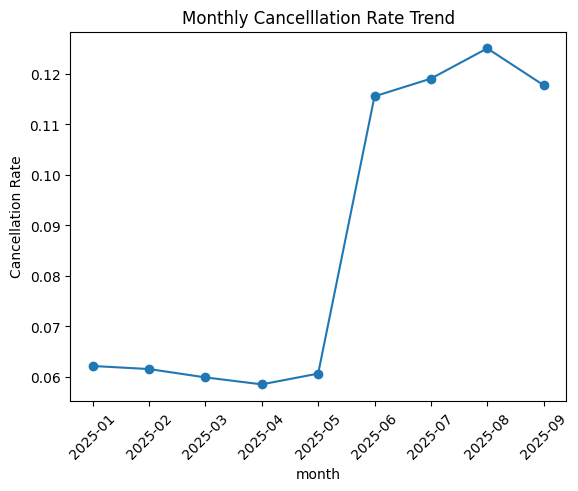

In [ ]:
monthly_cancel = clean_data.groupby('month')['is_cancelled'].mean()

import matplotlib.pyplot as plt

monthly_cancel.plot(marker='o')
plt.title('Monthly Cancelllation Rate Trend')
plt.ylabel('Cancellation Rate')
plt.xticks(rotation=45)
plt.show()

🔹 PART 3 — City-wise Cancellation Impact

In [ ]:
city_cancel = clean_data.groupby(['customer_city','phase'])['is_cancelled'].mean().reset_index()

In [ ]:
type(city_cancel)


pandas.core.frame.DataFrame

In [ ]:
city_cancel_pivot = city_cancel.pivot(index='customer_city', columns='phase', values='is_cancelled').reset_index()
city_cancel_pivot = city_cancel_pivot.fillna(0)

In [ ]:
city_cancel_pivot['Pre-Crisis'] = city_cancel_pivot['Pre-Crisis']*100
city_cancel_pivot['Crisis'] = city_cancel_pivot['Crisis']*100

In [ ]:

city_cancel_pivot['increase_%'] = city_cancel_pivot['Crisis'] - city_cancel_pivot['Pre-Crisis']

In [ ]:
top_cancel_cities = city_cancel_pivot.sort_values(by='increase_%', ascending=False).head(5)
top_cancel_cities

phase,customer_city,Crisis,Pre-Crisis,increase_%
5,Kolkata,7.142857,3.302197,3.840660
1,Bengaluru,7.185050,3.379480,3.805570
6,Mumbai,6.933484,3.294487,3.638997
2,Chennai,7.043454,3.431106,3.612347
0,Ahmedabad,6.643508,3.085774,3.557734


# question 5 Delivery SLA: Measure average delivery time across phases. Did SLA  compliance worsen significantly in the crisis period? 

In [ ]:
sla_phase = clean_data.groupby('phase')['actual_delivery_time_mins'].mean().reset_index()
sla_phase

,phase,actual_delivery_time_mins
0,Crisis,60.117647
1,Pre-Crisis,39.522424


In [ ]:
sla_phase.rename(columns={'actual_delivery_time_mins': 'avg_delivery_time'}, inplace=True)
sla_phase

,phase,avg_delivery_time
0,Crisis,60.117647
1,Pre-Crisis,39.522424


In [ ]:
clean_data['on_time'] = (
    clean_data['actual_delivery_time_mins'] <= clean_data['expected_delivery_time_mins']
).astype(int)

In [ ]:
sla_compliance = clean_data.groupby('phase')['on_time'].mean().reset_index()
sla_compliance['sla_%'] = sla_compliance['on_time'] * 100
sla_compliance

,phase,on_time,sla_%
0,Crisis,0.122031,12.203054
1,Pre-Crisis,0.436049,43.604907


Monthly trend

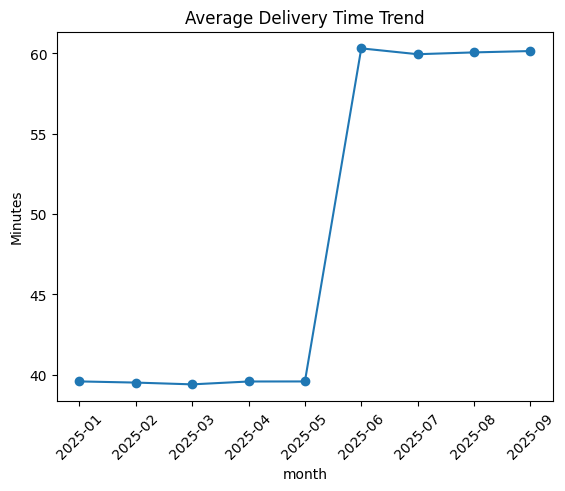

In [ ]:
monthly_sla = clean_data.groupby('month')['actual_delivery_time_mins'].mean()

import matplotlib.pyplot as plt

monthly_sla.plot(marker='o')
plt.title('Average Delivery Time Trend')
plt. ylabel("Minutes")
plt.xticks(rotation=45)
plt.show()

# Ouestion 6 Ratings Fluctuation: Track average customer rating month-by-month. Which  months saw the sharpest drop? 

In [ ]:
monthly_rating = clean_data.groupby('month')['rating'].mean()
monthly_rating

month
2025-01    2.142695
2025-02    2.052817
2025-03    2.211388
2025-04    2.025529
2025-05    2.110894
2025-06    1.139008
2025-07    1.184861
2025-08    1.031409
2025-09    1.017426
Name: rating, dtype: float64

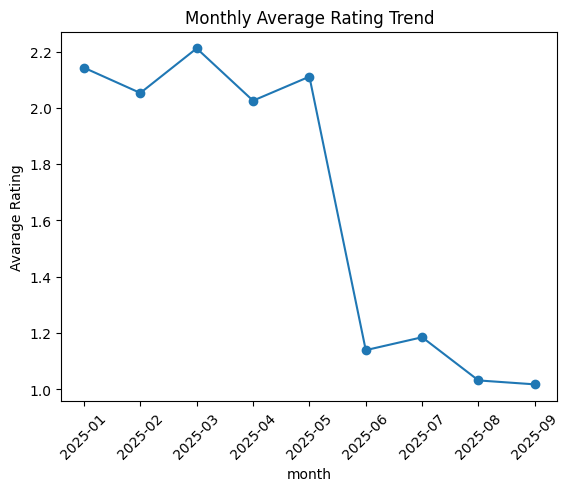

In [ ]:
import matplotlib.pyplot as plt

monthly_rating.plot(marker='o')
plt.title("Monthly Average Rating Trend")
plt.ylabel("Avarage Rating")
plt.xticks(rotation=45)
plt.show()

In [ ]:
rating_drop = monthly_rating.diff()
rating_drop

month
2025-01         NaN
2025-02   -0.089878
2025-03    0.158571
2025-04   -0.185859
2025-05    0.085365
2025-06   -0.971886
2025-07    0.045853
2025-08   -0.153452
2025-09   -0.013983
Name: rating, dtype: float64

In [ ]:
rating_drop.sort_values().head(3)

month
2025-06   -0.971886
2025-04   -0.185859
2025-08   -0.153452
Name: rating, dtype: float64

# 7. Sentiment Insights: During the crisis period, identify the most frequently occurring negative keywords in customer review texts. (Hint: Use a Word Cloud visual in Power BI to visualize the findings.) 

Step 1 — Filter Crisis + Negative Reviews

In [ ]:
negative_reviews = clean_data[
    (clean_data['phase'] == 'Crisis') &
    (clean_data['sentiment_score'] < 0)
]

In [ ]:
text = " ".join(negative_reviews['review_text'].astype(str))

In [ ]:
import re

text = text.lower()
text = re.sub(r'[^a-z\s]', '', text)

In [ ]:
from collections import Counter

stop_words = [
      'the','and','is','in','it','of','to','a','for','on','with','this',
    'that','then','than','was','very','but','not','had','have','they','you','i'
]

words = text.split()
filtered_words = [word for word in words if word not in stop_words]

In [ ]:
word_counts = Counter(filtered_words)

top_words = word_counts.most_common(20)
top_words

[('food', 4941),
 ('quality', 2226),
 ('issue', 2073),
 ('packaging', 1627),
 ('good', 1596),
 ('safety', 1076),
 ('bad', 972),
 ('taste', 972),
 ('stale', 971),
 ('served', 971),
 ('recommended', 942),
 ('late', 904),
 ('cold', 668),
 ('portion', 658),
 ('size', 658),
 ('smaller', 658),
 ('expected', 658),
 ('worth', 655),
 ('price', 655),
 ('average', 645)]

In [ ]:
import pandas as pd

top_words_df = pd.DataFrame(top_words, columns=['word','count'])
top_words_df

,word,count
0,food,4941
1,quality,2226
2,issue,2073
3,packaging,1627
4,good,1596
5,safety,1076
6,bad,972
7,taste,972
8,stale,971
9,served,971


In [ ]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


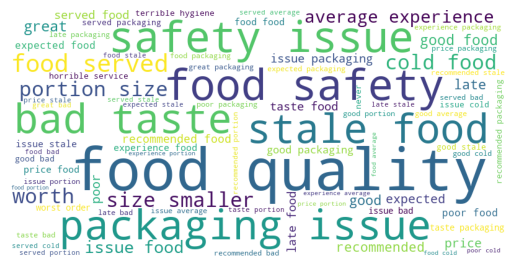

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wc)
plt.axis('off')
plt.show()

# Question 8 Revenue Impact: Estimate revenue loss from pre-crisis vs crisis (based on subtotal, discount, and delivery fee). 

In [ ]:
clean_data['revenue'] = (
    clean_data['subtotal_amount'] - clean_data['discount_amount'] + clean_data['delivery_fee']
)

In [ ]:
revenu_phase = clean_data.groupby('phase')['revenue'].sum().reset_index()
revenu_phase

,phase,revenue
0,Crisis,10940151.31
1,Pre-Crisis,37620965.05


In [ ]:
pre_rev = revenu_phase[revenu_phase['phase'] == 'Pre-Crisis']['revenue'].values[0]
crisis_rev = revenu_phase[revenu_phase['phase'] == 'Crisis']['revenue'].values[0]

revenue_loss_pct = ((pre_rev - crisis_rev) / pre_rev) * 100
revenue_loss_pct


np.float64(70.92006732028263)

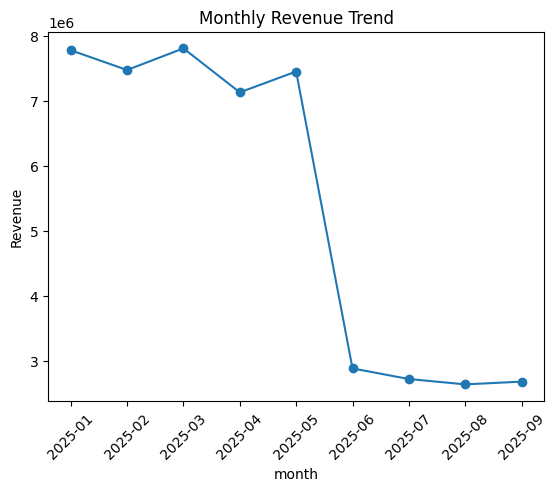

In [ ]:
monthly_revenue = clean_data.groupby('month')['revenue'].sum()

import matplotlib.pyplot as plt

monthly_revenue.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

# Question 9 Loyalty Impact: Among customers who placed five or more orders before the crisis, determine how many stopped ordering during the crisis, and out of those, how many had an average rating above 4.5?

In [ ]:
pre_orders = clean_data[clean_data['phase'] == 'Pre-Crisis']

customer_pre_counts = pre_orders.groupby('customer_id')['order_id'].count().reset_index()

customer_pre_counts.rename(columns={'order_id': 'pre_orders'}, inplace=True)

In [ ]:
customer_pre_counts.head()
customer_pre_counts.columns

Index(['customer_id', 'pre_orders'], dtype='object')

In [ ]:
loyal_customers = customer_pre_counts[customer_pre_counts['pre_orders'] >= 5]

In [ ]:
crisis_orders = clean_data[clean_data['phase'] == 'Crisis']

customer_crisis_counts = crisis_orders.groupby('customer_id')['order_id'].count().reset_index()
customer_crisis_counts.rename(columns={'order_id': 'crisis_orders'}, inplace=True)

In [ ]:
customer_merge = loyal_customers.merge(
    customer_crisis_counts,
    on='customer_id',
    how='left'
)

In [ ]:
churned_customer = customer_merge[customer_merge['crisis_orders'] == 0]

In [ ]:
customer_rating = clean_data.groupby('customer_id')['rating'].mean().reset_index()
customer_rating.rename(columns={'rating': 'avg_rating'}, inplace=True)

In [ ]:
churned_customer =churned_customer.merge(
    customer_rating,
    on='customer_id',
    how='left'
) 

In [ ]:
high_value_churn = churned_customer[churned_customer['avg_rating']>4.5]

In [ ]:
total_loyal = loyal_customers.shape[0]
total_churned = churned_customer.shape[0]
high_rating_churned = high_value_churn.shape[0]

total_loyal, total_churned, high_rating_churned

(58, 0, 0)

In [ ]:
customer_merge.sort_values('crisis_orders').head(10)

,customer_id,pre_orders,crisis_orders
1,CUST014076,5,1.0
6,CUST033937,5,1.0
21,CUST076309,6,1.0
40,CUST136053,5,1.0
52,CUST187661,5,1.0
43,CUST146179,5,1.0
54,CUST192705,5,1.0
57,CUST197169,5,1.0
29,CUST105415,6,2.0
0,CUST011220,5,NaN


In [ ]:
customer_merge['drop_pct'] = (
    (customer_merge['pre_orders'] - customer_merge['crisis_orders'])
    / customer_merge['pre_orders']
) * 100

loyal_drop_customers = customer_merge[customer_merge['drop_pct'] >= 50]
loyal_drop_customers.shape[0]

9

In [ ]:
customer_merge['crisis_orders'] = customer_merge['crisis_orders'].fillna(0)

In [ ]:
churned_customers = customer_merge[customer_merge['crisis_orders'] == 0]

In [ ]:
total_loyal = loyal_customers.shape[0]
total_churned = churned_customers.shape[0]

high_value_churn = churned_customers.merge(customer_rating, on='customer_id', how='left')
high_rating_churned = high_value_churn[high_value_churn['avg_rating'] > 4.5].shape[0]

total_loyal, total_churned, high_rating_churned

(58, 49, 0)

In [ ]:
customer_merge.sort_values('crisis_orders').head(10)

,customer_id,pre_orders,crisis_orders,drop_pct
0,CUST011220,5,0.0,NaN
2,CUST020252,5,0.0,NaN
3,CUST026722,5,0.0,NaN
4,CUST032044,5,0.0,NaN
7,CUST034992,5,0.0,NaN
5,CUST032334,5,0.0,NaN
9,CUST041121,6,0.0,NaN
8,CUST036233,5,0.0,NaN
12,CUST042658,5,0.0,NaN
13,CUST054308,5,0.0,NaN


# question 10. Customer Lifetime Decline: Which high-value customers (top 5% by total spend before the crisis) showed the largest drop in order frequency and ratings during the crisis? What common patterns (e.g., location, cuisine preference, delivery delays) do they share? 

In [ ]:
pre_data = clean_data[clean_data['phase'] == 'Pre-Crisis']

In [ ]:
customer_spend = pre_data.groupby('customer_id')['revenue'].sum().reset_index()
customer_spend.rename(columns={'revenue': 'total_spend'}, inplace=True)

In [ ]:
threshold = customer_spend['total_spend'].quantile(0.95)

high_value_customers = customer_spend[customer_spend['total_spend'] >= threshold]

In [ ]:
order_counts = clean_data.groupby(['customer_id', 'phase'])['order_id'].count().reset_index()

order_pivot = order_counts.pivot(index='customer_id', columns='phase', values='order_id').reset_index()
order_pivot = order_pivot.fillna(0)

In [ ]:
order_counts = clean_data.groupby(['customer_id', 'phase'])['order_id'].count().reset_index()

order_pivot = order_counts.pivot(index='customer_id', columns='phase', values='order_id').reset_index()
order_pivot = order_pivot.fillna(0)

In [ ]:
rating_phase = clean_data.groupby(['customer_id', 'phase'])['rating'].mean().reset_index()

rating_pivot = rating_phase.pivot(index='customer_id', columns='phase', values='rating').reset_index()
rating_pivot = rating_pivot.fillna(0)

In [ ]:
customer_analysis = high_value_customers.merge(order_pivot, on='customer_id', how='left')
customer_analysis = customer_analysis.merge(rating_pivot, on='customer_id', how='left')

In [ ]:
customer_analysis.columns

Index(['customer_id', 'total_spend', 'Crisis_x', 'Pre-Crisis_x', 'Crisis_y',
       'Pre-Crisis_y'],
      dtype='object')

In [ ]:
customer_analysis['order_drop_pct'] = (
    (customer_analysis['Pre-Crisis_x'] - customer_analysis['Crisis_x'])
    / customer_analysis['Pre-Crisis_x']
) * 100

customer_analysis['rating_drop'] = (
    customer_analysis['Pre-Crisis_y'] - customer_analysis['Crisis_y']
)

In [ ]:
top_decline_customers = customer_analysis.sort_values(
    by='order_drop_pct', ascending=False
).head(10)

top_decline_customers

,customer_id,total_spend,Crisis_x,Pre-Crisis_x,Crisis_y,Pre-Crisis_y,order_drop_pct,rating_drop
4341,CUST199925,1001.94,0.0,2.0,0.0,2.150000,100.0,2.150000
0,CUST000020,1139.19,0.0,3.0,0.0,3.033333,100.0,3.033333
4340,CUST199922,928.51,0.0,3.0,0.0,4.733333,100.0,4.733333
2,CUST000088,1340.03,0.0,3.0,0.0,4.600000,100.0,4.600000
3,CUST000163,931.05,0.0,2.0,0.0,2.000000,100.0,2.000000
4322,CUST199238,1119.59,0.0,3.0,0.0,2.900000,100.0,2.900000
4321,CUST199228,1194.43,0.0,3.0,0.0,3.100000,100.0,3.100000
4320,CUST199216,936.02,0.0,3.0,0.0,2.966667,100.0,2.966667
4319,CUST199215,938.63,0.0,1.0,0.0,4.900000,100.0,4.900000
4318,CUST199192,1452.10,0.0,3.0,0.0,1.500000,100.0,1.500000


In [ ]:
customer_patterns = clean_data.merge(
    top_decline_customers[['customer_id']],
    on='customer_id',
    how='inner'
)

In [ ]:
customer_patterns = clean_data.merge(
    top_decline_customers[['customer_id']],
    on='customer_id',
    how='inner'
)

In [ ]:
customer_patterns['cuisine_type'].value_counts().head(5)

cuisine_type
Biryani         7
Fast Food       5
Chinese         4
North Indian    4
South Indian    3
Name: count, dtype: int64

In [ ]:
customer_patterns['delivery_delay'] = (
    customer_patterns['actual_delivery_time_mins'] -
    customer_patterns['expected_delivery_time_mins']
)

customer_patterns['delivery_delay'].mean()

np.float64(1.8846153846153846)

# Priority Cities (High Risk)

In [35]:
city_orders = clean_data.groupby(['customer_city','phase'])['order_id'].count().reset_index()
city_pivot = city_orders.pivot(index='customer_city', columns='phase', values='order_id').fillna(0)

city_pivot['decline_pct'] = (
    (city_pivot['Pre-Crisis'] - city_pivot['Crisis'])
    / city_pivot['Pre-Crisis']
) * 100

city_pivot.sort_values(by='decline_pct', ascending=False).head(5)


phase,Crisis,Pre-Crisis,decline_pct
customer_city,,,
Bengaluru,9311,31277,70.230521
Mumbai,5322,17848,70.181533
Ahmedabad,2303,7648,69.887552
Pune,2662,8817,69.808325
Delhi,4704,15580,69.807445


#  Behavior Shift (High → Low value orders)

In [36]:
aov = clean_data.groupby('phase')['total_amount'].mean()
aov

phase
Crisis        309.393419
Pre-Crisis    330.571009
Name: total_amount, dtype: float64

<Axes: xlabel='month'>

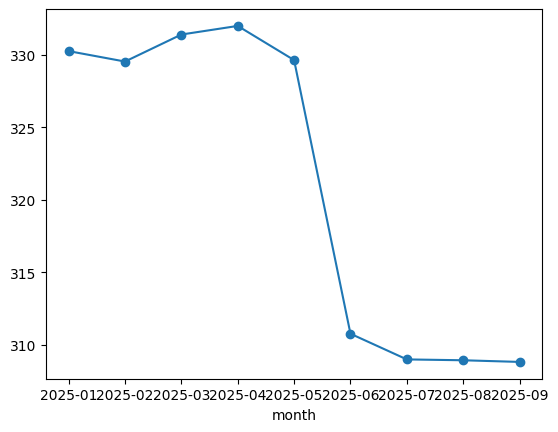

In [37]:
monthly_aov = clean_data.groupby('month')['total_amount'].mean()
monthly_aov.plot(marker='o')

# Feedback Trend (Very powerful)

<Axes: xlabel='month'>

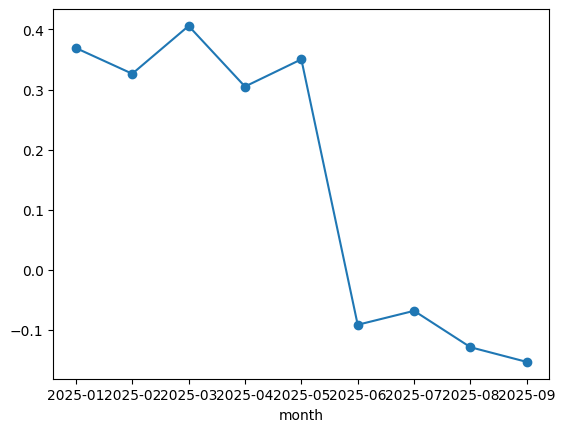

In [38]:
monthly_sentiment = clean_data.groupby('month')['sentiment_score'].mean()

monthly_sentiment.plot(marker='o')


<Axes: xlabel='month'>

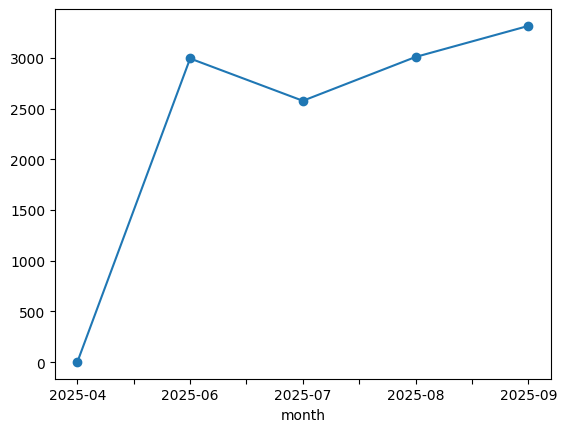

In [39]:
negative_reviews = clean_data[clean_data['sentiment_score'] < 0]

monthly_negative = negative_reviews.groupby('month')['order_id'].count()

monthly_negative.plot(marker='o')

# Restaurant Churn Analysis
 Step 1 — Orders by restaurant type

In [40]:
restaurant_orders = clean_data.groupby(['partner_type','phase'])['order_id'].count().reset_index()

restaurant_pivot = restaurant_orders.pivot(index='partner_type', columns='phase', values='order_id').fillna(0)

restaurant_pivot['decline_pct'] = (
    (restaurant_pivot['Pre-Crisis'] - restaurant_pivot['Crisis'])
    / restaurant_pivot['Pre-Crisis']
) * 100

restaurant_pivot


phase,Crisis,Pre-Crisis,decline_pct
partner_type,,,
Cloud Kitchen,10586,33718,68.604306
Restaurant,24774,80088,69.066527


Step 2 — Small vs Large restaurants

In [41]:
restaurant_size = clean_data[clean_data['phase']=='Pre-Crisis'] \
    .groupby('restaurant_id')['order_id'].count().reset_index()

restaurant_size['size'] = restaurant_size['order_id'].apply(
    lambda x: 'Large' if x >= 100 else 'Small'
)

Step 3 — Merge + analyze

In [42]:
clean_data = clean_data.merge(restaurant_size[['restaurant_id','size']], on='restaurant_id', how='left')

size_orders = clean_data.groupby(['size','phase'])['order_id'].count().reset_index()

size_pivot = size_orders.pivot(index='size', columns='phase', values='order_id').fillna(0)

size_pivot['decline_pct'] = (
    (size_pivot['Pre-Crisis'] - size_pivot['Crisis'])
    / size_pivot['Pre-Crisis']
) * 100

size_pivot

phase,Crisis,Pre-Crisis,decline_pct
size,,,
Small,35236,113806,69.038539


# Lapsed Customers (Who can return?)

In [43]:
churned_customers.head()

NameError: name 'churned_customers' is not defined

In [44]:
pre_orders = clean_data[clean_data['phase'] == 'Pre-Crisis']

customer_pre_counts = pre_orders.groupby('customer_id')['order_id'].count().reset_index()
customer_pre_counts.rename(columns={'order_id': 'pre_orders'}, inplace=True)

loyal_customers = customer_pre_counts[customer_pre_counts['pre_orders'] >= 5]



In [45]:
crisis_orders = clean_data[clean_data['phase'] == 'Crisis']

customer_crisis_counts = crisis_orders.groupby('customer_id')['order_id'].count().reset_index()
customer_crisis_counts.rename(columns={'order_id': 'crisis_orders'}, inplace=True)


In [46]:
customer_merge = loyal_customers.merge(
    customer_crisis_counts,
    on='customer_id',
    how='left'
)

In [47]:
customer_merge['crisis_orders'] = customer_merge['crisis_orders'].fillna(0)

In [48]:
churned_customers = customer_merge[customer_merge['crisis_orders'] == 0]

In [49]:
churned_customers.head()

,customer_id,pre_orders,crisis_orders
0,CUST011220,5,0.0
2,CUST020252,5,0.0
3,CUST026722,5,0.0
4,CUST032044,5,0.0
5,CUST032334,5,0.0


In [52]:
customer_rating = clean_data.groupby('customer_id')['rating'].mean().reset_index()

customer_rating.rename(columns={'rating': 'avg_rating'}, inplace=True)

In [53]:
customer_rating.head()

,customer_id,avg_rating
0,CUST000007,5.000000
1,CUST000008,0.000000
2,CUST000009,0.000000
3,CUST000010,2.733333
4,CUST000011,0.000000


In [54]:
churn_analysis = churned_customers.merge(customer_rating, on='customer_id', how='left')

In [56]:
clean_data['revenue'] = (
    clean_data['subtotal_amount']
    - clean_data['discount_amount']
    + clean_data['delivery_fee']
)

In [57]:
customer_spend_total = clean_data.groupby('customer_id')['revenue'].sum().reset_index()

In [58]:
churn_analysis = churned_customers.merge(customer_rating, on='customer_id', how='left')

# Add spend
customer_spend_total = clean_data.groupby('customer_id')['revenue'].sum().reset_index()
churn_analysis = churn_analysis.merge(customer_spend_total, on='customer_id', how='left')

In [59]:
churn_analysis['return_score'] = (
    churn_analysis['avg_rating'] * 0.5 +
    churn_analysis['revenue'] * 0.0001
)

In [60]:
top_recoverable = churn_analysis.sort_values(by='return_score', ascending=False).head(10)

top_recoverable

,customer_id,pre_orders,crisis_orders,avg_rating,revenue,return_score
41,CUST163628,5,0.0,3.80,2397.56,2.139756
29,CUST109617,5,0.0,3.78,1718.25,2.061825
46,CUST188511,5,0.0,3.66,1291.78,1.959178
26,CUST107785,5,0.0,3.50,2053.41,1.955341
31,CUST110481,5,0.0,3.46,1897.79,1.919779
25,CUST103227,5,0.0,2.86,2130.75,1.643075
10,CUST042658,5,0.0,2.84,1426.62,1.562662
44,CUST178428,5,0.0,2.82,1421.53,1.552153
24,CUST086938,5,0.0,2.80,1377.02,1.537702
17,CUST072644,5,0.0,2.70,1874.84,1.537484
